In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import requests
from tqdm import tqdm
import geopandas as gpd

In [4]:
data = pd.read_excel('Реестр.xlsx', skiprows=2)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [15]:
data.head()

,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
0,1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
1,2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
2,3,""" СТРОЙТЕХНИКА - М "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1025204418293,5263039399,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,10.07.2022,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
3,4,"""БАЗИС"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1025204411682,5263025484,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1.0
4,5,"""БЕЛАГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800039276,7801123215,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.07.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603520 entries, 0 to 603519
Data columns (total 23 columns):
 #   Column                                                                    Non-Null Count   Dtype  
---  ------                                                                    --------------   -----  
 0   № п/п                                                                     603520 non-null  int64  
 1   Наименование / ФИО                                                        603520 non-null  object 
 2   Тип субъекта                                                              603520 non-null  object 
 3   Категория                                                                 603520 non-null  object 
 4   ОГРН                                                                      603520 non-null  int64  
 5   ИНН                                                                       603520 non-null  int64  
 6   Основной вид деятельности                           

In [7]:
data['Тип субъекта'].unique()

array(['Юридическое лицо', 'Индивидуальный предприниматель'], dtype=object)

In [8]:
data['Категория'].unique()

array(['Не является субъектом МСП', 'Микропредприятие',
       'Малое предприятие', 'Среднее предприятие'], dtype=object)

In [9]:
data['Основной вид деятельности'].unique()

array(['41.2 Строительство жилых и нежилых зданий',
       '41.20 Строительство жилых и нежилых зданий',
       '41.10 Разработка строительных проектов',
       '41 Строительство зданий', '41.1 Разработка строительных проектов'],
      dtype=object)

In [10]:
data_41_2 = data[
    (data['Тип субъекта'] == 'Юридическое лицо') &
    ((data['Категория'] == 'Малое предприятие') | (data['Категория'] == 'Среднее предприятие')) &
    ((data['Основной вид деятельности'] == '41.2 Строительство жилых и нежилых зданий') | (data['Основной вид деятельности'] == '41.20 Строительство жилых и нежилых зданий'))
]

In [12]:
data_41_2.shape

(10573, 23)

In [14]:
data_41_2['ИНН'].nunique()

10573

In [43]:
class Parser:
    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            "User-Agent": "Mozilla/5.0",
            "Referer": "https://bo.nalog.gov.ru/"
        })

    def get_company_id_by_inn(self, inn):
        url = f"https://bo.nalog.gov.ru/advanced-search/organizations/search"
        params = {
            "query": inn,
            "page": 0,
            "size": 20
        }
        try:
            response = self.session.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            
            if data.get("content"):
                return data["content"][0].get("id")
        except Exception as e:
            print(f"Request failed: {e}")
            return None
        
        return None

    def get_financial_report(self, company_id):
        try:
            url = f"https://bo.nalog.gov.ru/nbo/organizations/{company_id}/bfo/"
            response = self.session.get(url, timeout=10)
            response.raise_for_status()
            return response.json()
        except Exception as e:
            print(f"Request failed: {e}")
            return None


    def parse_ebit(self, report_json, inn):
        result = {
            'inn': [],
            'year': [],
            'revenue': [],
            'clear_profit': [],
            'taxes': [],
            'interest': [],
            'ebit': []
        }
        for year_data in report_json:
            year = year_data.get('period')
            corrections = year_data.get("typeCorrections", [])
            if not corrections:
                continue
    
            fin = corrections[0].get("correction", {}).get("financialResult", {})
    
            revenue = fin.get("current2110", 0)
            clear_profit = fin.get("current2400", 0)
            taxes = fin.get("current2410", 0)
            interest = fin.get("current2330", 0)
    
            ebit = clear_profit + taxes + interest
    
            result['inn'].append(inn)
            result['year'].append(year)
            result['revenue'].append(revenue)
            result['clear_profit'].append(clear_profit)
            result['taxes'].append(taxes)
            result['interest'].append(interest)
            result['ebit'].append(ebit)
    
        return result


    def get_ebit_for_inn(self, inn: str):
        company_id = self.get_company_id_by_inn(inn)
        if not company_id:
            print(f"Компания с ИНН {inn} не найдена")
            return {}
        report = self.get_financial_report(company_id)
        if not report:
            return []
        return self.parse_ebit(report, inn)


In [44]:
pars = Parser()

In [55]:
inn_list = data_41_2['ИНН'].astype(str)

In [58]:
all_company = []
batch_size = 500   
save_path = "ebit_save.csv"

for i, inn in enumerate(tqdm(inn_list, desc="Parsing companies")):
    company_ebit = pars.get_ebit_for_inn(inn)

    if company_ebit:
        all_company.append(pd.DataFrame(company_ebit))
    if (i + 1) % batch_size == 0:
        if all_company:
            temp_df = pd.concat(all_company, ignore_index=True)
            temp_df.to_csv(save_path, index=False)

if all_company:
    df_ebit = pd.concat(all_company, ignore_index=True)
    df_ebit.to_csv("ebit_final.csv", index=False)
else:
    df_ebit = pd.DataFrame()

Parsing companies:   0%|                     | 13/10573 [00:04<49:38,  3.54it/s]

Компания с ИНН 5009106346 не найдена


Parsing companies:   4%|▊                   | 446/10573 [02:28<44:14,  3.82it/s]

Компания с ИНН 2014256831 не найдена


Parsing companies:   5%|█                   | 578/10573 [03:16<51:02,  3.26it/s]

...

Parsing companies:  99%|█████████████████▊| 10475/10573 [24:06<00:09, 10.59it/s]

Компания с ИНН 7702376423 не найдена


Parsing companies: 100%|█████████████████▉| 10548/10573 [24:14<00:02,  9.64it/s]

Компания с ИНН 9724149604 не найдена


Parsing companies: 100%|██████████████████| 10573/10573 [24:17<00:00,  7.25it/s]


In [60]:
df_ebit

,inn,year,revenue,clear_profit,taxes,interest,ebit
0,5038038838,2024,112540.0,-20129.0,-191.0,1521.0,-18799.0
1,5038038838,2023,108966.0,-20913.0,-248.0,3334.0,-17827.0
2,5038038838,2022,118633.0,19518.0,-336.0,141.0,19323.0
3,5038038838,2021,184044.0,3080.0,-320.0,5601.0,8361.0
4,5027064258,2024,930280.0,3594.0,-2629.0,0.0,965.0
...,...,...,...,...,...,...,...
39702,2002001476,2021,251982.0,1049.0,-262.0,0.0,787.0
39703,702005585,2024,18397.0,1030.0,277.0,0.0,1307.0
39704,702005585,2023,5049.0,750.0,188.0,0.0,938.0
39705,702005585,2022,36804.0,-2233.0,-464.0,0.0,-2697.0


In [61]:
df_ebit_for_year = df_ebit.groupby('year')['ebit'].sum()

In [62]:
df_ebit_for_year

year
2021     77142760.0
2022    104083232.0
2023    131242975.0
2024    154007849.0
2025      -133196.0
Name: ebit, dtype: float64

In [65]:
df_ebit.groupby('year')['inn'].nunique()

year
2021    10029
2022    10338
2023     9805
2024     9221
2025      314
Name: inn, dtype: int64

- В 2025 году наблюдается отрицательное значение EBIT, что объясняется малым количеством компаний, предоставивших отчет за этот год. 
- Также в каждый год количество компаний отличается, поэтому среднее и медианное значение EBIT должны быть более объективными показателями чем сумма.

In [69]:
summary = df_ebit[df_ebit['year'] != '2025'].groupby('year').agg(
    total_ebit=('ebit', 'sum'),
    avg_ebit=('ebit', 'mean'),
    median_ebit=('ebit', 'median'),
    companies=('inn', 'nunique')
)

In [70]:
summary

,total_ebit,avg_ebit,median_ebit,companies
year,,,,
2021,77142760.0,7691.969289,2359.0,10029
2022,104083232.0,10068.023989,2269.5,10338
2023,131242975.0,13385.311066,2574.0,9805
2024,154007849.0,16701.859777,2840.0,9221


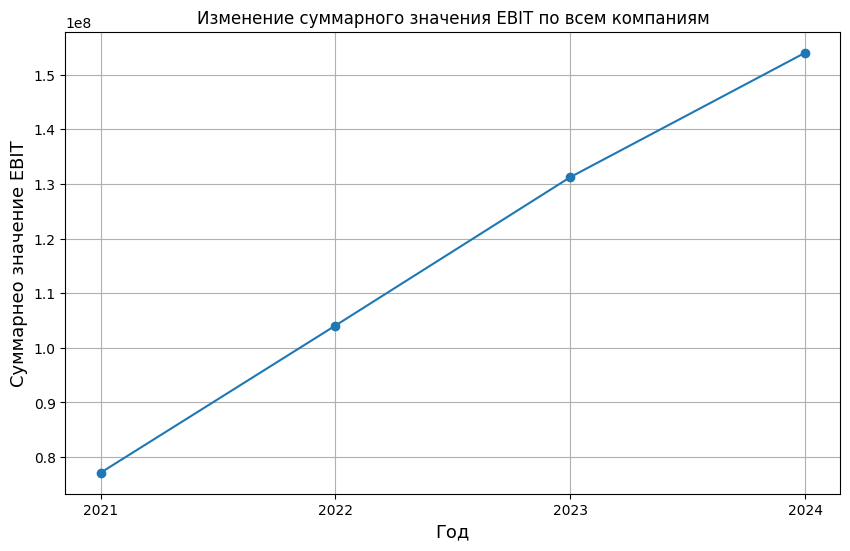

In [97]:
plt.figure(figsize=(10, 6))
plt.plot(summary['total_ebit'], marker='o')
plt.title("Изменение суммарного значения EBIT по всем компаниям") 
plt.xlabel("Год", fontsize=13)
plt.ylabel("Суммарнео значение EBIT", fontsize=13)
plt.grid()
plt.show()

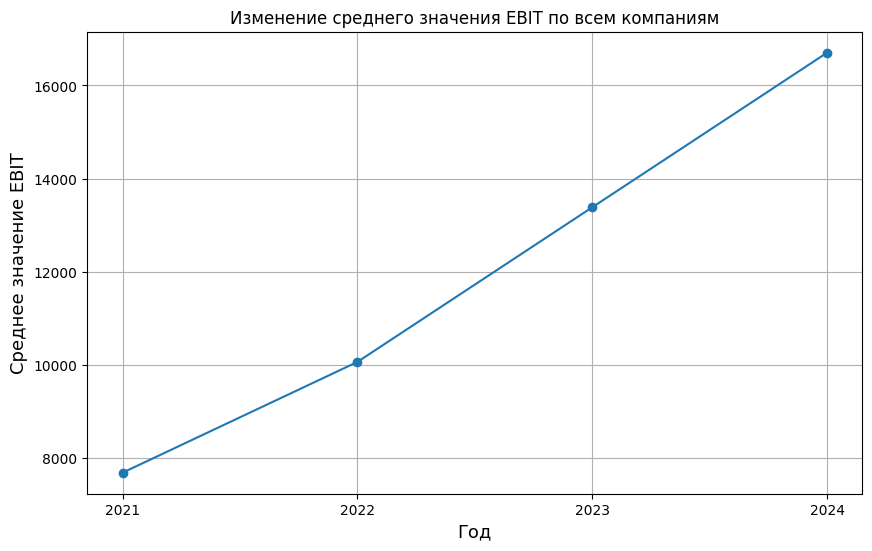

In [99]:
plt.figure(figsize=(10, 6))
plt.plot(summary['avg_ebit'], marker='o')
plt.title("Изменение среднего значения EBIT по всем компаниям") 
plt.xlabel("Год", fontsize=13)
plt.ylabel("Среднее значение EBIT", fontsize=13)
plt.grid()
plt.show()

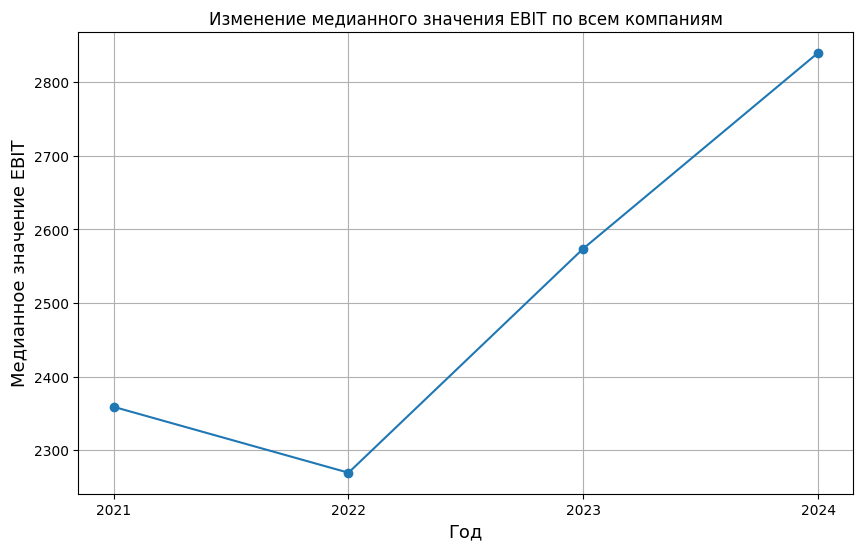

In [100]:
plt.figure(figsize=(10, 6))
plt.plot(summary['median_ebit'], marker='o')
plt.title("Изменение медианного значения EBIT по всем компаниям") 
plt.xlabel("Год", fontsize=13)
plt.ylabel("Медианное значение EBIT", fontsize=13) 
plt.grid()
plt.show()

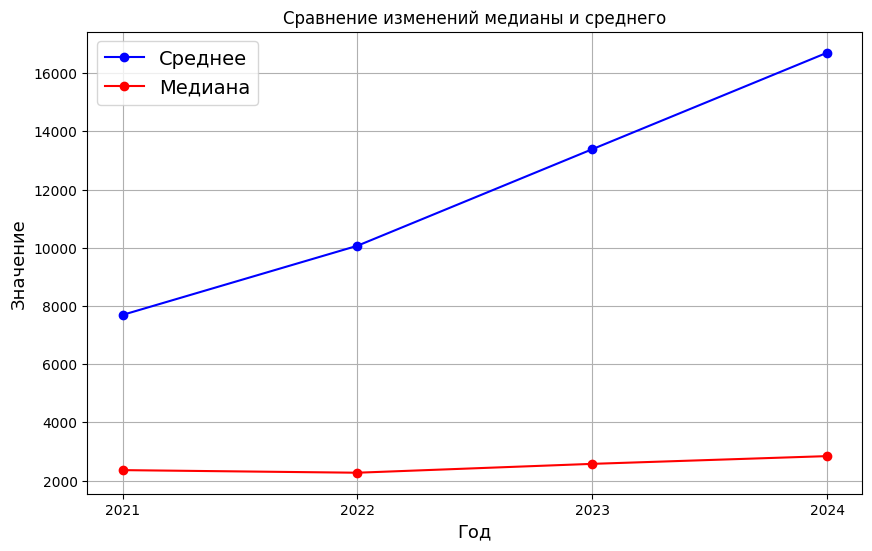

In [101]:
plt.figure(figsize=(10, 6))
plt.plot(summary['avg_ebit'], marker='o', color='blue', label='Среднее')
plt.plot(summary['median_ebit'], marker='o', color='red', label='Медиана')
plt.legend(fontsize=14)
plt.title("Сравнение изменений медианы и среднего") 
plt.xlabel("Год", fontsize=13)
plt.ylabel("Значение", fontsize=13)
plt.grid()
plt.show()

В период с 2021 по 2024 год наблюдается рост суммарного, среднего и медианного значений показателя EBIT в строительной отрасли. Это свидетельствует об общем увеличении операционной прибыли компаний данной отрасли.
При этом среднее значение стабильно превышает медианное, что говорит о том, что наибольший вклад в метрику EBIT вносят крупные компании.
Подводя итог, можно сказать, что отрасль строительства является перспективной с точки зрения показателя EBIT.

In [480]:
df_marginality = df_ebit[['inn', 'year', 'revenue', 'ebit']].copy()
df_marginality = df_marginality[df_marginality['year'] != '2025']
df_marginality['marginality'] = (df_marginality['ebit'] / df_marginality['revenue'] * 100).round(2)

In [481]:
df_marginality['year'].unique()

array(['2024', '2023', '2022', '2021'], dtype=object)

In [482]:
df_marginality.isna().sum()

inn              0
year             0
revenue          0
ebit             0
marginality    883
dtype: int64

In [483]:
(df_marginality['marginality'] == float('-inf')).sum()

np.int64(1072)

In [484]:
(df_marginality['marginality'] == float('inf')).sum()

np.int64(360)

In [485]:
df_marginality = df_marginality.replace([np.inf, -np.inf], np.nan)

In [486]:
df_marginality = df_marginality.dropna()

In [487]:
summary_marginality = df_marginality.groupby('year').agg(
    avg_marginality=('marginality', 'mean'),
    median_marginality=('marginality', 'median'),
    companies=('inn', 'nunique')
)
summary_marginality

,avg_marginality,median_marginality,companies
year,,,
2021,-143.387186,1.76,9807
2022,-302.402208,1.71,9830
2023,-250.172004,1.94,9082
2024,-204.734457,2.21,8359


Среднее значение маржинальности намного меньше медианного, что означает, что в отрасли есть несколько компаний с очень большой отрицательной рентабельностью, которые сильно влияют на среднее значение

In [488]:
(df_marginality['marginality'] < 0).groupby(df_marginality['year']).mean()

year
2021    0.173651
2022    0.178840
2023    0.174191
2024    0.177533
Name: marginality, dtype: float64

Доля компаний с отрицательной маржинальностью стабильно находится в районе 17%

In [184]:
df_clear_profit = df_ebit[(df_ebit['year'] == '2021') | (df_ebit['year'] == '2024')]

In [185]:
df_clear_profit

,inn,year,revenue,clear_profit,taxes,interest,ebit
0,5038038838,2024,112540.0,-20129.0,-191.0,1521.0,-18799.0
3,5038038838,2021,184044.0,3080.0,-320.0,5601.0,8361.0
4,5027064258,2024,930280.0,3594.0,-2629.0,0.0,965.0
7,5027064258,2021,249375.0,3984.0,-737.0,0.0,3247.0
8,5027006369,2024,429496.0,28998.0,-8184.0,705.0,21519.0
...,...,...,...,...,...,...,...
39698,2301032458,2021,44640.0,1600.0,-400.0,0.0,1200.0
39699,2002001476,2024,596622.0,1656.0,-414.0,0.0,1242.0
39702,2002001476,2021,251982.0,1049.0,-262.0,0.0,787.0
39703,702005585,2024,18397.0,1030.0,277.0,0.0,1307.0


In [186]:
df_clear_profit = df_clear_profit.pivot_table(
    values='clear_profit',
    columns='year',
    index='inn'
)

In [187]:
df_clear_profit

year,2021,2024
inn,,
1001001619,-38058.0,8420.0
1001010821,444206.0,939525.0
1001062611,547.0,146.0
1001090344,10153.0,-5025.0
1001127234,11783.0,8526.0
...,...,...
9731069188,761.0,892.0
9731074269,832.0,NaN
9731076259,42.0,308.0


In [188]:
df_clear_profit.isna().sum()

year
2021     265
2024    1073
dtype: int64

In [189]:
df_clear_profit.dropna(inplace=True)

In [190]:
proc = ((df_clear_profit['2024'] / df_clear_profit['2021'] - 1) * 100).round()
proc

inn
1001001619   -122.0
1001010821    112.0
1001062611    -73.0
1001090344   -149.0
1001127234    -28.0
              ...  
9731058806      9.0
9731066839   -274.0
9731069188     17.0
9731076259    633.0
9731079316   -100.0
Length: 8956, dtype: float64

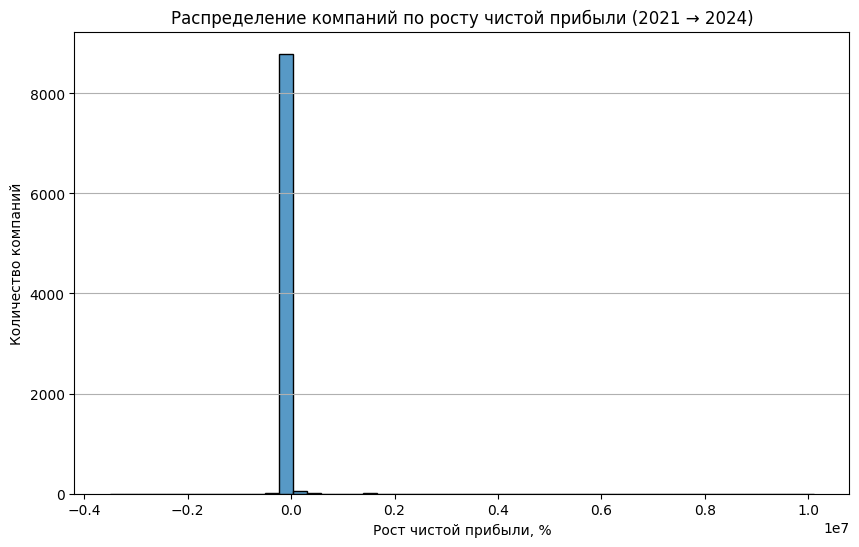

In [199]:
plt.figure(figsize=(10,6))
sns.histplot(proc.values, bins=50, edgecolor='k')
plt.xlabel("Рост чистой прибыли, %")
plt.ylabel("Количество компаний")
plt.title("Распределение компаний по росту чистой прибыли (2021 → 2024)")
plt.grid(axis='y')
plt.show()

Данный график является неинформативным. Попробуем убрать 5% компаний с наибольшим и наименьшим ростом 

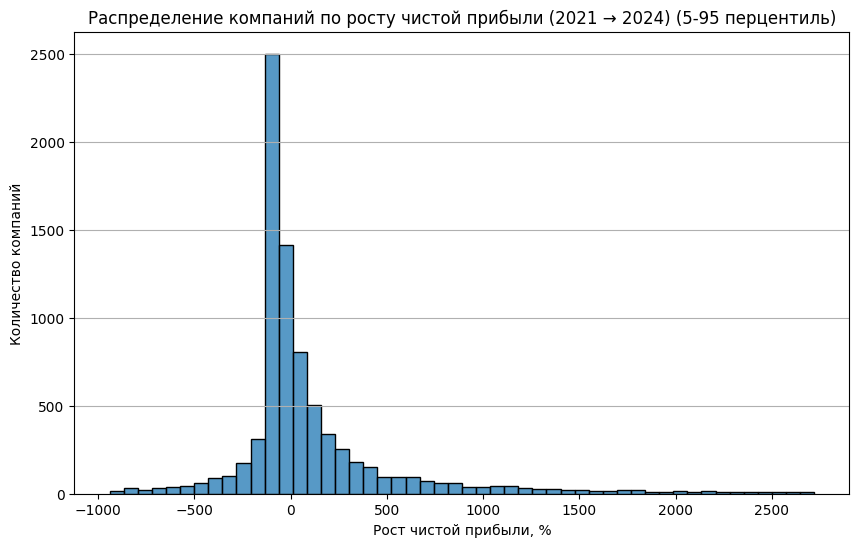

In [200]:
q_low, q_high = proc.quantile([0.05, 0.95])
proc_clip = proc[(proc >= q_low) & (proc <= q_high)]

plt.figure(figsize=(10,6))
sns.histplot(proc_clip, bins=50)
plt.ylabel("Количество компаний")
plt.xlabel("Рост чистой прибыли, %")
plt.title("Распределение компаний по росту чистой прибыли (2021 → 2024) (5-95 перцентиль)")
plt.grid(axis='y')
plt.show()

После удаления 5% компаний с экстремальными значениями видно, что большая часть строительных компаний показывает снижение чистой прибыли в период 2021–2024 годов. Это говорит о том, что, несмотря на рост EBIT, чистая прибыль многих компаний сокращается, что стоит учитывать при оценке перспективности отрасли.

In [491]:
top_500 = df_ebit.nlargest(500, 'revenue')[['revenue', 'inn']]

In [492]:
df_region = data_41_2[['ИНН','Регион']]

In [493]:
df_region = df_region.rename(columns={'ИНН': 'inn'}).astype(str)

In [494]:
top_500_with_region = pd.merge(top_500, df_region, on=['inn'])
top_500_with_region['region_name'] = top_500_with_region['Регион'].apply(lambda x: x.split(' - ')[1].strip())

In [495]:
top_500_with_region.head()

,revenue,inn,Регион,region_name
0,77138000.0,8601049319,86 - Ханты-Мансийский автономный округ - Югра,Ханты-Мансийский автономный округ
1,14352296.0,7718894438,77 - г.Москва,г.Москва
2,12516249.0,7708409097,77 - г.Москва,г.Москва
3,11931988.0,7708309350,20 - Чеченская Республика,Чеченская Республика
4,11857538.0,7708309350,20 - Чеченская Республика,Чеченская Республика


In [3]:
map_df = gpd.read_file("map/ne_10m_admin_1_states_provinces.shp")
russia_regions = map_df[map_df['admin'] == 'Russia']
russia_regions = russia_regions.to_crs(epsg=3857)

In [517]:
russia_regions.head()

,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
115,Admin-1 states provinces,2,RUS-2400,2400,RU-AL,None,RU,1,Gorno-Altay,Gorno-Altayskaya A.Obl.|Respublika Altay|Oirot...,...,None,None,None,None,None,None,None,None,None,"POLYGON ((9775668.482 6303047.504, 9764542.965..."
135,Admin-1 states provinces,2,RUS-2335,2335,RU-PSK,None,RU,1,Pskov,Pskovskaya Oblast,...,None,None,None,None,None,None,None,None,None,"POLYGON ((3082927.477 7833310.232, 3076962.454..."
210,Admin-1 states provinces,2,RUS-2371,2371,RU-KDA,None,RU,1,Krasnodar,Cossacks of the Black Sea|Kuban|Kubanskaya|Yek...,...,None,None,None,None,None,None,None,None,None,"POLYGON ((4510623.963 5389183.498, 4506194.466..."
212,Admin-1 states provinces,2,RUS-2280,2280,RU-KC,None,RU,1,Karachay-Cherkess,Karaçay-Çerkes|Karachay-Cherkessiya|Karachayev...,...,None,None,None,None,None,None,None,None,None,"POLYGON ((4568828.711 5368434.924, 4565411.67 ..."
213,Admin-1 states provinces,2,RUS-2304,2304,RU-KB,None,RU,1,Kabardin-Balkar,Kabardin A.S.S.R.|Kabardino-Balkarskaya A.S.S....,...,None,None,None,None,None,None,None,None,None,"POLYGON ((4743903.16 5332844.97, 4741751.69 53..."


In [498]:
top_500_with_region['region_code'] = (
    top_500_with_region['Регион']
    .str.split(' - ')
    .str[0]
    .str.zfill(2)
)

In [520]:
top_500_with_region['Регион'].unique()

array(['86 - Ханты-Мансийский автономный округ - Югра', '77 - г.Москва',
       '20 - Чеченская Республика', '40 - Калужская область',
       '54 - Новосибирская область', '50 - Московская область',
       '78 - г.Санкт-Петербург', '16 - Республика Татарстан (Татарстан)',
       '34 - Волгоградская область', '65 - Сахалинская область',
       '25 - Приморский край', '72 - Тюменская область',
       '61 - Ростовская область', '43 - Кировская область',
       '23 - Краснодарский край', '76 - Ярославская область',
       '38 - Иркутская область', '59 - Пермский край',
       '62 - Рязанская область', '13 - Республика Мордовия',
       '32 - Брянская область', '69 - Тверская область',
       '47 - Ленинградская область', '66 - Свердловская область',
       '06 - Республика Ингушетия', '31 - Белгородская область',
       '89 - Ямало-Ненецкий автономный округ', '64 - Саратовская область',
       '14 - Республика Саха (Якутия)', '02 - Республика Башкортостан',
       '18 - Удмуртская Республи

In [521]:
region_code_to_iso = {
    "86": "RU-KHM",  # ХМАО
    "77": "RU-MOW",  # Москва
    "20": "RU-CE",   # Чечня
    "40": "RU-KLU",  # Калужская
    "54": "RU-NVS",  # Новосибирская
    "50": "RU-MOS",  # Московская область
    "78": "RU-SPE",  # Санкт-Петербург
    "16": "RU-TA",   # Татарстан
    "34": "RU-VGG",  # Волгоградская
    "65": "RU-SAK",  # Сахалин
    "25": "RU-PRI",  # Приморский край
    "72": "RU-TYU",  # Тюменская
    "61": "RU-ROS",  # Ростовская
    "43": "RU-KIR",  # Кировская
    "23": "RU-KDA",  # Краснодарский край
    "76": "RU-YAR",  # Ярославская
    "38": "RU-IRK",  # Иркутская
    "59": "RU-PER",  # Пермский край
    "62": "RU-RYA",  # Рязанская
    "13": "RU-MO",   # Мордовия
    "32": "RU-BRY",  # Брянская
    "69": "RU-TVE",  # Тверская
    "47": "RU-LEN",  # Ленинградская
    "66": "RU-SVE",  # Свердловская
    "06": "RU-IN",   # Ингушетия
    "31": "RU-BEL",  # Белгородская
    "89": "RU-YAN",  # ЯНАО
    "64": "RU-SAR",  # Саратовская
    "14": "RU-SA",   # Саха (Якутия)
    "02": "RU-BA",   # Башкортостан
    "18": "RU-UD",   # Удмуртия
    "52": "RU-NIZ",  # Нижегородская
    "74": "RU-CHE",  # Челябинская
    "63": "RU-SAM",  # Самарская
    "91": "RU-CR",   # Крым
    "92": "RU-SEV",  # Севастополь
    "48": "RU-LIP",  # Липецкая
    "21": "RU-CU",   # Чувашия
    "29": "RU-ARK",  # Архангельская
    "73": "RU-ULY",  # Ульяновская
    "07": "RU-KB",   # Кабардино-Балкария
    "70": "RU-TOM",  # Томская
    "36": "RU-VOR",  # Воронежская
    "35": "RU-VLG",  # Вологодская
    "55": "RU-OMS",  # Омская
    "28": "RU-AMU",  # Амурская
    "67": "RU-SMO",  # Смоленская
    "57": "RU-ORL",  # Орловская
    "24": "RU-KYA",  # Красноярский край
    "27": "RU-KHA",  # Хабаровский край
    "26": "RU-STA",  # Ставропольский край
    "15": "RU-SE",   # Северная Осетия
    "39": "RU-KGD",  # Калининградская
    "05": "RU-DA",   # Дагестан
    "37": "RU-IVA",  # Ивановская
    "44": "RU-KOS",  # Костромская
    "30": "RU-AST",  # Астраханская
    "42": "RU-KEM",  # Кемеровская
    "22": "RU-ALT",  # Алтайский край
    "56": "RU-ORE",  # Оренбургская
}


In [522]:
top_500_with_region['iso_3166_2'] = (
    top_500_with_region['region_code']
    .map(region_code_to_iso)
)

In [523]:
russia_centroids = russia_regions.set_index('iso_3166_2').centroid

In [524]:
top_500_with_region['geometry'] = top_500_with_region['iso_3166_2'].map(lambda x: russia_centroids.get(x))
top_500_with_region = top_500_with_region.dropna(subset=['geometry'])
companies_gdf = gpd.GeoDataFrame(top_500_with_region, geometry='geometry', crs=russia_regions.crs)

In [525]:
companies_gdf['size'] = (companies_gdf['revenue'] / companies_gdf['revenue'].max()) * 100

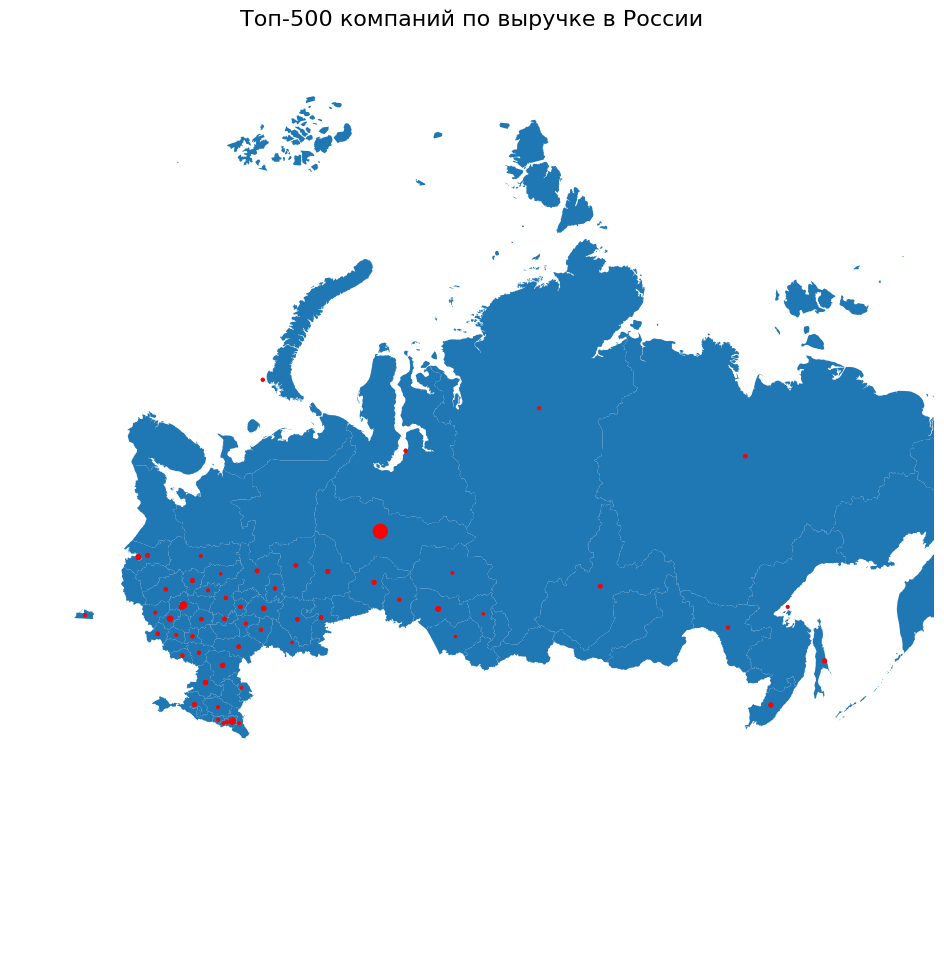

In [532]:
fig, ax = plt.subplots(figsize=(12, 12))
russia_regions.plot(ax=ax)
companies_gdf.plot(ax=ax, markersize=companies_gdf['size'], color='red')

ax.set_xlim(1000000, 18000000)  
ax.set_ylim(1000000, 18000000)

ax.set_title("Топ-500 компаний по выручке в России", fontsize=16)
ax.axis('off')
plt.show()

In [541]:
top_500_with_region.groupby('Регион')['inn'].count().sort_values(ascending=False)

Регион
77 - г.Москва                                    140
78 - г.Санкт-Петербург                            50
50 - Московская область                           41
16 - Республика Татарстан (Татарстан)             34
23 - Краснодарский край                           25
66 - Свердловская область                         18
54 - Новосибирская область                        12
02 - Республика Башкортостан                      10
65 - Сахалинская область                           8
25 - Приморский край                               7
61 - Ростовская область                            7
40 - Калужская область                             7
20 - Чеченская Республика                          7
74 - Челябинская область                           6
21 - Чувашская Республика - Чувашия                6
86 - Ханты-Мансийский автономный округ - Югра      6
72 - Тюменская область                             6
34 - Волгоградская область                         5
59 - Пермский край                     

In [550]:
top_500_with_region[(top_500_with_region['Регион'] == '77 - г.Москва') |
    (top_500_with_region['Регион'] == '50 - Московская область')]['inn'].count() / top_500_with_region['inn'].count() * 100

np.float64(36.71399594320487)

In [549]:
top_500_with_region[top_500_with_region['Регион'] == '78 - г.Санкт-Петербург']['inn'].count() / top_500_with_region['inn'].count() * 100

np.float64(10.141987829614605)

Более 36% крупнейших строительных компаний зарегистрированы в Москве и Московской области, более 10% в Санкт-Петербурге, также выделяются  Татарстан, Краснодарский край и Свердловская область, что можно объяснить большей потребностью в строительства жилья и инфраструктурных проектов в крупных регионах.